In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

In [40]:
veriler = pd.read_csv("maaslar_yeni.csv")

In [41]:
x = veriler.iloc[:,2:3] # ilk başta 5 e kadar baktık ama p value değerleri çok yüksek çıktığı için bağımlı değişkeni düşük olan tek 2. kolonu alıyoruz
y = veriler.iloc[:,5:]
X = x.values
Y = y.values

In [42]:
#linear regression
from sklearn.linear_model import LinearRegression
lin_reg = LinearRegression()
lin_reg.fit(X,Y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [43]:
import statsmodels.api as sm
print("Linear R2 Değeri:", r2_score(Y, lin_reg.predict(X)))

Linear R2 Değeri: 0.5285811733746243


In [44]:
#polynomial regression
from sklearn.preprocessing import PolynomialFeatures
poly_reg = PolynomialFeatures(degree=4)
x_poly = poly_reg.fit_transform(X)
lin_reg2 = LinearRegression()
lin_reg2.fit(x_poly,y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [45]:
#tahminler
print('poly OLS')
print("Polynomial R2 Değeri:", r2_score(Y, lin_reg2.predict(poly_reg.fit_transform(X))))

poly OLS
Polynomial R2 Değeri: 0.8174873280442542


In [46]:
#verilerin olceklenmesi
from sklearn.preprocessing import StandardScaler

sc1=StandardScaler()
x_olcekli = sc1.fit_transform(X)
sc2=StandardScaler()
y_olcekli = np.ravel(sc2.fit_transform(Y.reshape(-1,1)))

In [47]:
from sklearn.svm import SVR

svr_reg = SVR(kernel='rbf')
svr_reg.fit(x_olcekli,y_olcekli)

,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,tol,0.001
,C,1.0
,epsilon,0.1
,shrinking,True
,cache_size,200
,verbose,False
,max_iter,-1


In [48]:
print('SVR OLS')
print("SVR R2 Değeri:", r2_score(y_olcekli, svr_reg.predict(x_olcekli)))

SVR OLS
SVR R2 Değeri: 0.5841869084594333


In [49]:
#Decision Tree Regresyon Veriyi belirli eşik değerlerine göre dallara ayırarak tahmin yapar. 
# Ölçekleme gerektirmez, bu yüzden orijinal X ve Y kullanılmış.
from sklearn.tree import DecisionTreeRegressor
r_dt = DecisionTreeRegressor(random_state=0)
r_dt.fit(X,Y)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [50]:
print('Decision Tree OLS')
print("Decision Tree R2 Değeri:", r2_score(Y, r_dt.predict(X)))

Decision Tree OLS
Decision Tree R2 Değeri: 0.8343186200100907


In [51]:
#Random Forest Regresyonu 10 farklı karar ağacı (n_estimators=10) oluşturur ve bunların ortalamasını alır. 
#Genelde tek bir ağaçtan daha kararlı sonuç verir.
from sklearn.ensemble import RandomForestRegressor
rf_reg=RandomForestRegressor(n_estimators = 10,random_state=0)
rf_reg.fit(X,Y.ravel())

,n_estimators,10
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [52]:
print('Random Forest OLS')
print("Random Forest R2 Değeri:", r2_score(Y, rf_reg.predict(X)))

Random Forest OLS
Random Forest R2 Değeri: 0.8284081476481634


tek parametreli olarak:                     3 parametreli:

Linear                                      Linear
R-squared:      0.942                       R-squared:      0.903

Polynomial                                  Polynomial
R-squared:      0.759                       R-squared:      0.680

SVR                                         SVR
R_squared:      0.770                       R_squared:      0.782

DT                                          DT
R-squared:      0.751                       R-squared:      0.679

RF                                          RF
R-squared:      0.719                       R-squared:      0.713

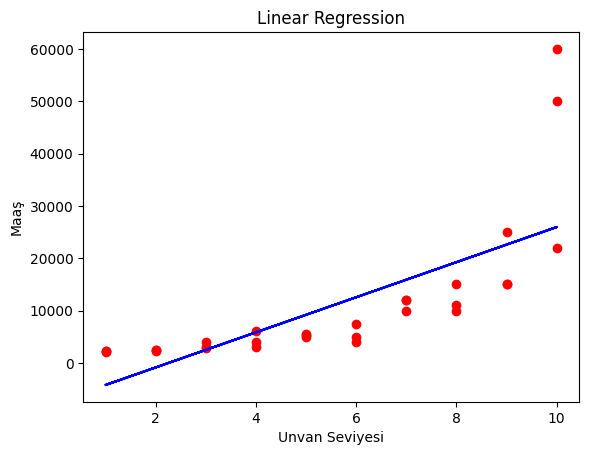

In [53]:
plt.scatter(X, Y, color='red') # Gerçek veriler (Nokta)
plt.plot(X, lin_reg.predict(X), color='blue') # Tahmin çizgisi
plt.title('Linear Regression')
plt.xlabel('Unvan Seviyesi')
plt.ylabel('Maaş')
plt.show()

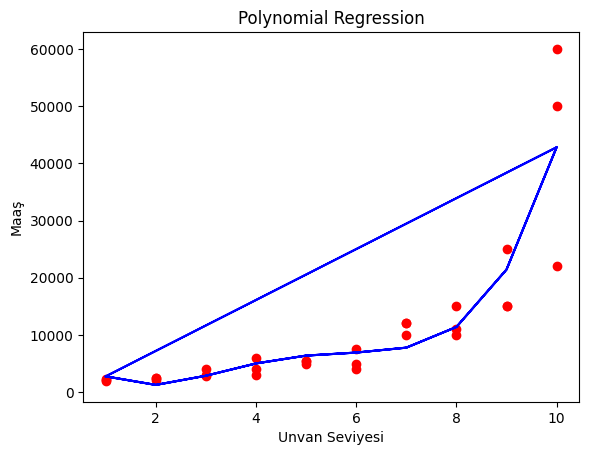

In [54]:
plt.scatter(X, Y, color='red')
# Tahmin için X değerlerini de polinoma çevirip öyle tahmin alıyoruz
plt.plot(X, lin_reg2.predict(poly_reg.fit_transform(X)), color='blue')
plt.title('Polynomial Regression')
plt.xlabel('Unvan Seviyesi')
plt.ylabel('Maaş')
plt.show()

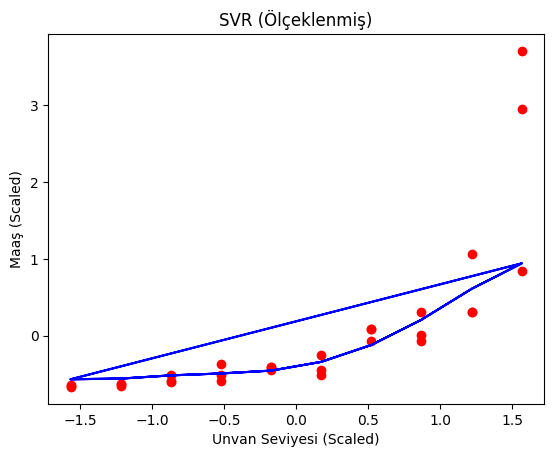

In [55]:
# Ölçeklenmiş verilerle görselleştirme
plt.scatter(x_olcekli, y_olcekli, color='red')
plt.plot(x_olcekli, svr_reg.predict(x_olcekli), color='blue')
plt.title('SVR (Ölçeklenmiş)')
plt.xlabel('Unvan Seviyesi (Scaled)')
plt.ylabel('Maaş (Scaled)')
plt.show()


C:\Users\OĞUZ\AppData\Local\Temp\ipykernel_18608\2433561067.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01) # 0.01 aralıklarla sayı üret


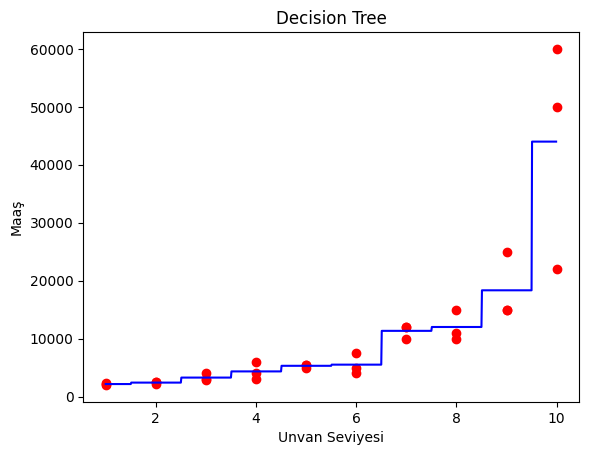

In [56]:
# Daha hassas bir çizim için X değerlerini sıklaştırıyoruz
X_grid = np.arange(min(X), max(X), 0.01) # 0.01 aralıklarla sayı üret
X_grid = X_grid.reshape((len(X_grid), 1)) # Boyutunu düzelt

plt.scatter(X, Y, color='red')
plt.plot(X_grid, r_dt.predict(X_grid), color='blue')
plt.title('Decision Tree')
plt.xlabel('Unvan Seviyesi')
plt.ylabel('Maaş')
plt.show()

C:\Users\OĞUZ\AppData\Local\Temp\ipykernel_18608\2997121708.py:1: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  X_grid = np.arange(min(X), max(X), 0.01)


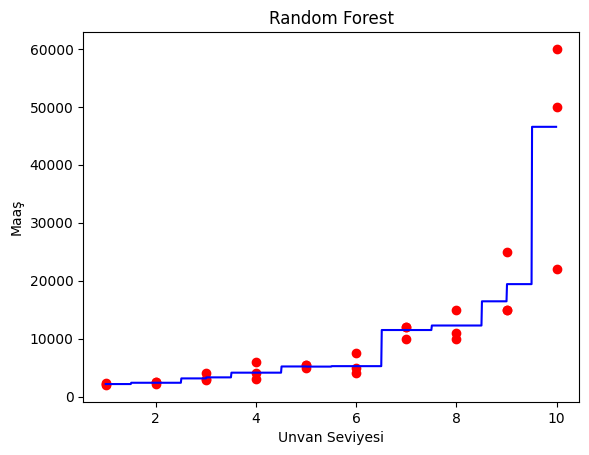

In [57]:
X_grid = np.arange(min(X), max(X), 0.01)
X_grid = X_grid.reshape((len(X_grid), 1))

plt.scatter(X, Y, color='red')
plt.plot(X_grid, rf_reg.predict(X_grid), color='blue')
plt.title('Random Forest')
plt.xlabel('Unvan Seviyesi')
plt.ylabel('Maaş')
plt.show()